# VaR & CVaR, three ways

**pyportfolios.com** · [/research/var-cvar-three-ways](https://pyportfolios.com/research/var-cvar-three-ways) · 60/40 SPY + AGG, 2003 – 2023 · NumPy · SciPy · Pandas · yfinance

One number, three recipes — and the recipes disagree exactly when it matters.
On a daily-rebalanced 60/40 equity/bond book we

1. compute 99% (and 95%) VaR and CVaR by **historical simulation**,
   **parametric** (normal and Student-t) and **Monte Carlo** (200,000 seeded draws),
2. backtest a rolling 250-day historical VaR out of sample, and
3. score the breach rate with Kupiec's proportion-of-failures test.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats

plt.rcParams["figure.figsize"] = (10, 5)
SEED = 42

## 1 · Data: two decades of the 60/40

SPY (S&P 500) and AGG (US aggregate bonds) from AGG's 2003 inception through
2023 — the GFC, the 2011 and 2018 wobbles, COVID, and 2022, the year the
diversifier failed. Daily-rebalanced 60/40.

In [2]:
px = yf.download(["SPY", "AGG"], start="2003-01-01", end="2024-01-01",
                 auto_adjust=True, progress=False)["Close"].dropna()
rets = px.pct_change().dropna()
port = 0.6 * rets["SPY"] + 0.4 * rets["AGG"]
rv = port.values
print(f"{len(port)} days, worst {port.idxmin().date()} ({port.min():.2%})")

5098 days, worst 2020-03-12 (-7.34%)


## 2 · Historical simulation

No model: VaR at level α is the empirical (1−α)-quantile of returns, negated;
CVaR is the mean return beyond it.

In [3]:
def hist_var_cvar(x, alpha=0.99):
    q = np.quantile(x, 1 - alpha)
    return -q, -x[x <= q].mean()

for a in (0.99, 0.95):
    v, c = hist_var_cvar(rv, a)
    print(f"historical {a:.0%}: VaR = {v:.3%}   CVaR = {c:.3%}")

historical 99%: VaR = 2.106%   CVaR = 3.161%
historical 95%: VaR = 1.023%   CVaR = 1.742%


## 3 · Parametric: normal, then Student-t

The variance–covariance formula, then the one-line tail fix: replace the
normal with a Student-t whose degrees of freedom are fitted by MLE.

In [4]:
mu, sd = rv.mean(), rv.std(ddof=1)
t_df, t_loc, t_scale = stats.t.fit(rv)
print(f"fitted Student-t df = {t_df:.2f}")

for a in (0.99, 0.95):
    z = stats.norm.ppf(1 - a)
    nv = -(mu + sd * z)
    tv = -(t_loc + t_scale * stats.t.ppf(1 - a, t_df))
    print(f"{a:.0%}  normal VaR {nv:.3%}   Student-t VaR {tv:.3%}")

fitted Student-t df = 1.93
99%  normal VaR 1.652%   Student-t VaR 2.562%
95%  normal VaR 1.159%   Student-t VaR 1.024%


## 4 · Monte Carlo

Simulate 200,000 seeded draws from the fitted Student-t and read the
empirical tail. On one linear book this must agree with the analytic t to
Monte-Carlo error — its value appears once the portfolio has optionality.

In [5]:
rng = np.random.default_rng(SEED)
draws = t_loc + t_scale * rng.standard_t(t_df, 200000)

for a in (0.99, 0.95):
    v, c = hist_var_cvar(draws, a)
    print(f"monte carlo {a:.0%}: VaR = {v:.3%}   CVaR = {c:.3%}")

monte carlo 99%: VaR = 2.564%   CVaR = 5.435%
monte carlo 95%: VaR = 1.024%   CVaR = 2.285%


## 5 · Backtest: rolling window + Kupiec

Forecast day *t*'s 99% VaR from the previous 250 days only, count
breaches, and test the rate with Kupiec's (1995) likelihood ratio
(χ²(1) under H₀: true breach probability = 1%).

In [6]:
WINDOW = 250
f_hist = port.rolling(WINDOW).quantile(0.01).shift(1).values
f_norm = (port.rolling(WINDOW).mean()
          + port.rolling(WINDOW).std(ddof=1) * stats.norm.ppf(0.01)).shift(1).values

def kupiec(x, n, p=0.01):
    phat = x / n
    ll0 = (n - x) * np.log(1 - p) + x * np.log(p)
    ll1 = (n - x) * np.log(1 - phat) + (x * np.log(phat) if x > 0 else 0.0)
    lr = -2 * (ll0 - ll1)
    return lr, stats.chi2.sf(lr, 1)

n, n_fc = len(rv), len(rv) - WINDOW
for name, f in (("hist", f_hist), ("normal", f_norm)):
    valid = ~np.isnan(f)
    x = int((rv[valid] < f[valid]).sum())
    lr, p = kupiec(x, n_fc)
    print(f"{name:>6}: {x} breaches / {n_fc} (expected {0.01 * n_fc:.1f})  "
          f"Kupiec LR = {lr:.2f}  p = {p:.4f}")

  hist: 76 breaches / 4848 (expected 48.5)  Kupiec LR = 13.45  p = 0.0002
normal: 137 breaches / 4848 (expected 48.5)  Kupiec LR = 109.24  p = 0.0000


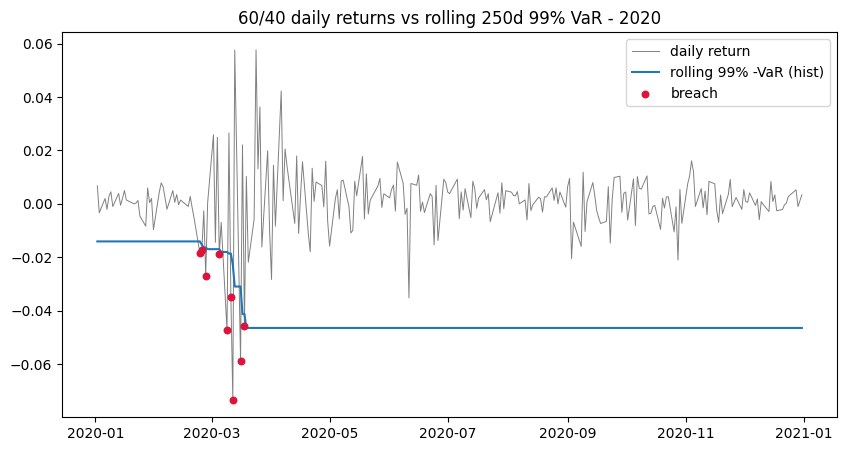

In [7]:
breach = rv < f_hist
year = port.index.year == 2020
plt.plot(port.index[year], rv[year], lw=0.7, color="grey", label="daily return")
plt.plot(port.index[year], f_hist[year], lw=1.5, label="rolling 99% -VaR (hist)")
plt.scatter(port.index[year & breach], rv[year & breach],
            s=22, color="crimson", zorder=3, label="breach")
plt.legend(); plt.title("60/40 daily returns vs rolling 250d 99% VaR - 2020");

## Takeaways

- The three recipes give materially different 99% VaRs on the same book; the
  normal sits lowest — fat tails are exactly what it assumes away.
- The fitted Student-t df is small: even a sleepy 60/40 book is far from Gaussian.
- Rolling historical VaR breaches too often, and the breaches cluster (March
  2020) — Kupiec rejects the 1% rate, which is the case for conditional models.
- CVaR comes free alongside each method and is the better number for limits.
- Never ship a VaR you have not backtested.

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*